In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow import keras
from keras import layers

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\SuNi\Downloads\heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
df['HeartDisease'] = (df['num'] > 0).astype(int)
df = df.drop(['id', 'dataset', 'num'], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,HeartDisease
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           920 non-null    int64  
 1   sex           920 non-null    str    
 2   cp            920 non-null    str    
 3   trestbps      861 non-null    float64
 4   chol          890 non-null    float64
 5   fbs           830 non-null    object 
 6   restecg       918 non-null    str    
 7   thalch        865 non-null    float64
 8   exang         865 non-null    object 
 9   oldpeak       858 non-null    float64
 10  slope         611 non-null    str    
 11  ca            309 non-null    float64
 12  thal          434 non-null    str    
 13  HeartDisease  920 non-null    int64  
dtypes: float64(5), int64(2), object(2), str(5)
memory usage: 133.5+ KB


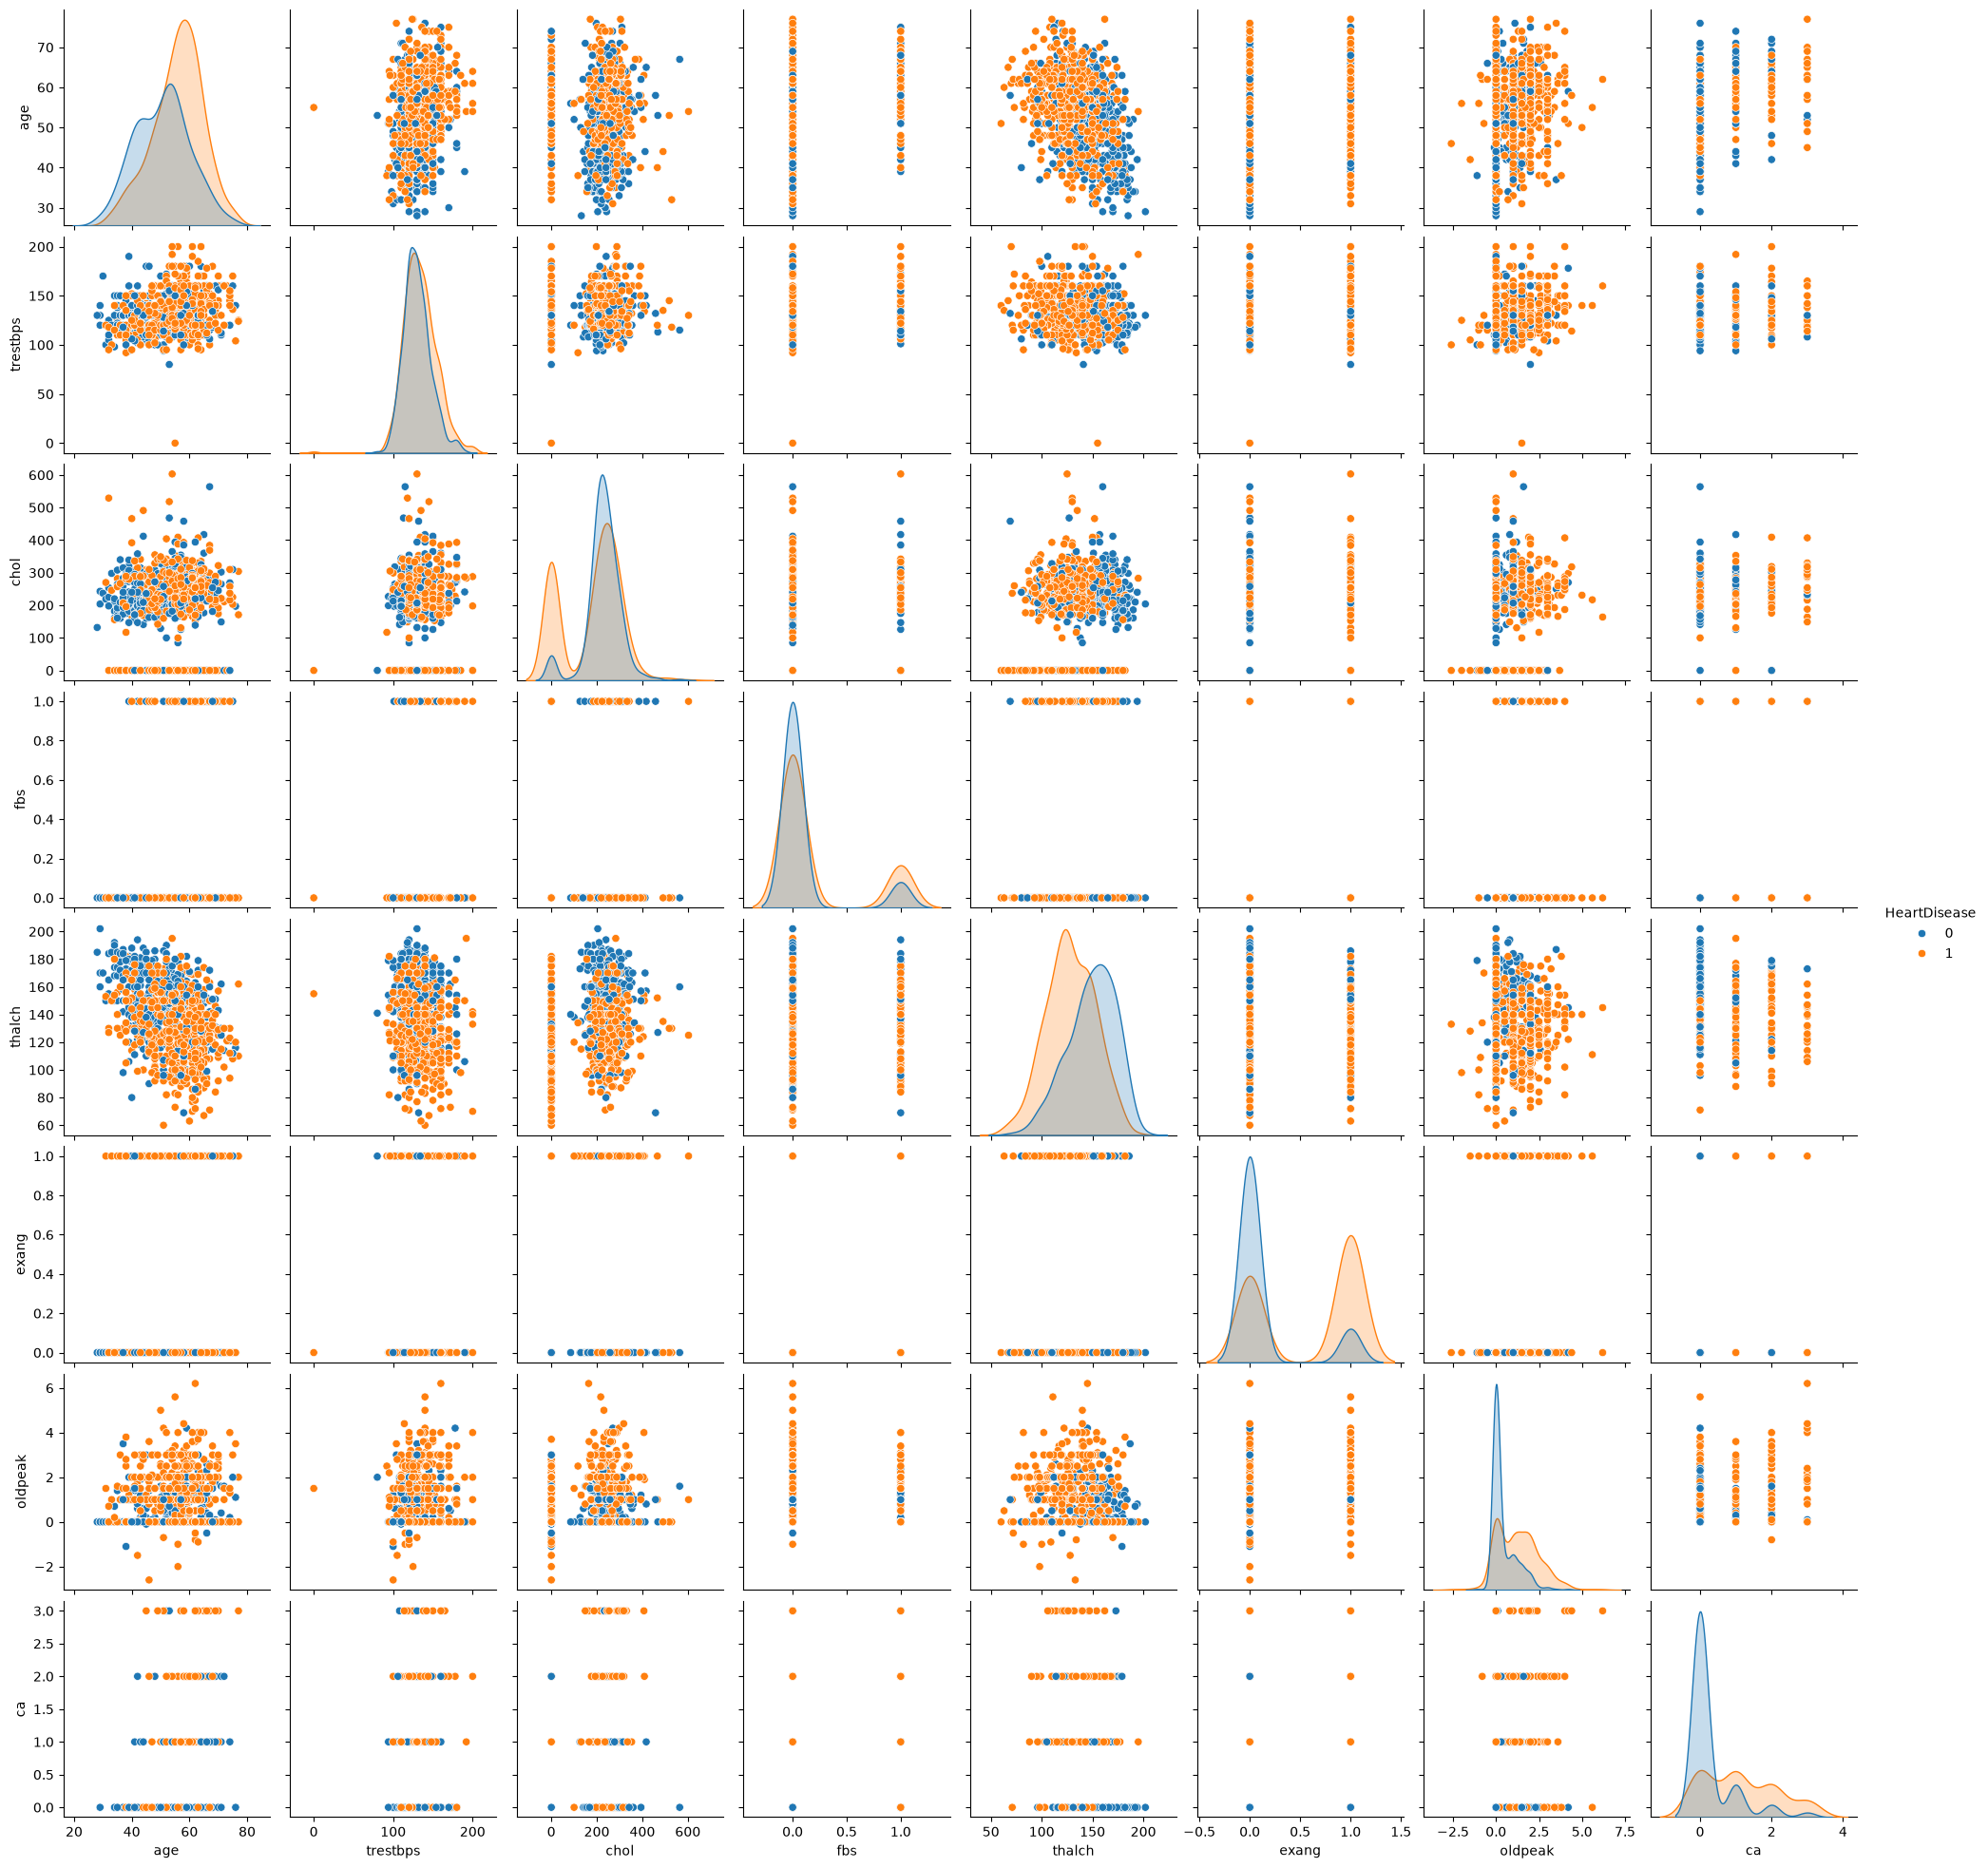

In [9]:
sns.pairplot(df, hue='HeartDisease')

In [10]:
word_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
le = LabelEncoder()
for col in word_cols:
    df[col] = le.fit_transform(df[col].astype(str))

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,HeartDisease
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,HeartDisease
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,0.789130,0.782609,131.995652,199.908696,0.345652,0.994565,137.692391,0.485870,0.853261,1.823913,0.227174,2.215217,0.553261
std,9.424685,0.408148,0.956350,18.451300,109.040171,0.649837,0.638767,25.145235,0.608085,1.058049,0.977146,0.628936,0.946551,0.497426
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,177.750000,0.000000,1.000000,120.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,140.000000,0.000000,0.500000,2.000000,0.000000,3.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,3.000000,0.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,2.000000,3.000000,202.000000,2.000000,6.200000,3.000000,3.000000,3.000000,1.000000


In [13]:
df.isnull().any()

age             False
sex             False
cp              False
trestbps        False
chol            False
fbs             False
restecg         False
thalch          False
exang           False
oldpeak         False
slope           False
ca              False
thal            False
HeartDisease    False
dtype: bool

In [14]:
X = df.drop(['HeartDisease'], axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
model = keras.Sequential([
    layers.Input(shape =(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

In [22]:
model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    verbose = 1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6020 - loss: 0.7168 - val_accuracy: 0.8041 - val_loss: 0.6229
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7194 - loss: 0.5718 - val_accuracy: 0.8514 - val_loss: 0.5527
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7619 - loss: 0.5080 - val_accuracy: 0.8243 - val_loss: 0.5072
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7585 - loss: 0.5092 - val_accuracy: 0.8378 - val_loss: 0.4699
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7806 - loss: 0.4646 - val_accuracy: 0.8311 - val_loss: 0.4478
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7908 - loss: 0.4587 - val_accuracy: 0.8311 - val_loss: 0.4290
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7959 - loss: 0.4459 - val_accuracy: 0.8378 - val_loss: 0.4089
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8027 - loss: 0.4499 - val_accuracy: 0.

In [23]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc*100:.2f}%")


Final Test Loss: 0.4976
Final Test Accuracy: 79.89%


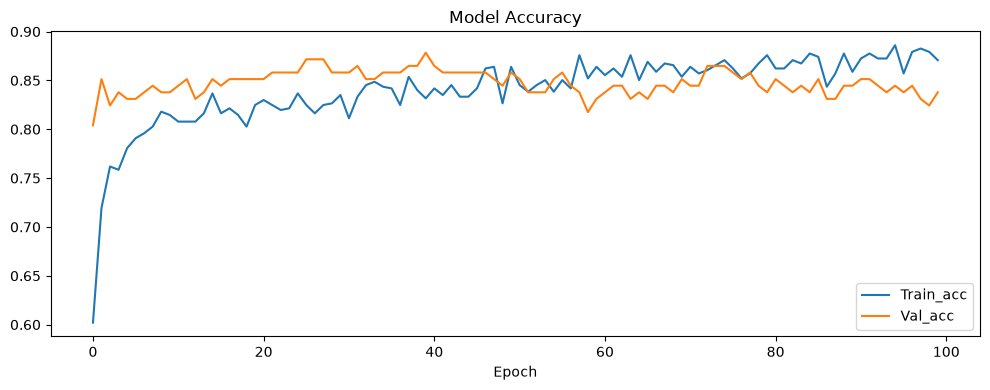

In [24]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train_acc')
plt.plot(history.history['val_accuracy'], label='Val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

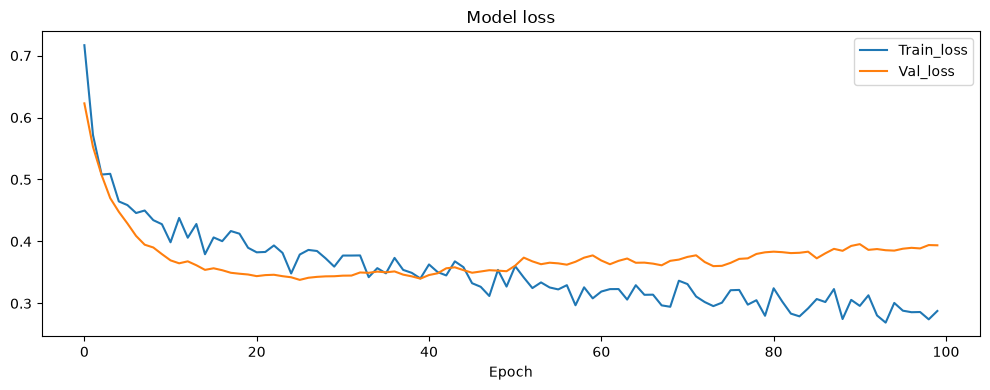

In [26]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train_loss')
plt.plot(history.history['val_loss'], label='Val_loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()